# Linear Regression 1
The `LinearRegression` estimator is usd to find equation of line:
$$
y = a_0 + a_1 x_1 + a_2 x_2 + \cdots
$$
where there are multiple $x$ values.
Geometrically, this is akin to fitting a plane to points in three dimensions, or fitting a hyperplane to points in higher dimensions.
Here $x_1$ , $x_2$, etc are features. Here **y is dependant variable, and x1,x2,etc are indep var.**

**NOTE: In medical domain, this could be relation between Systolic BP(y), BMI(x1), PTT(x2)**

**QUESTION:** If you had studied longer, would your overall scores get any better?

One way of answering this question is by having data on how long you studied for and what scores you got. We can then try to see if there is a pattern in that data, and if in that pattern, when you add to the hours, it also ends up adding to the scores percentage.

For instance, say you have an hour-score dataset, which contains entries such as 1.5h and 87.5% score. It could also contain 1.61h, 2.32h and 78%, 97% scores, respectively. The kind of data type that can have any intermediate value (or any level of 'granularity') is known as continuous data

Here we are trying to find equation of line, 
$$
y = a_0 + a_1 x_1 
$$

that can describe relation between $x_1$ (hours) and y (scores). $a_0$ is the intercept/bias and $a_1$ is the $x_1$-coefficient or the weight of $x_1$.

Regression is performed on continuous data
- Here I manually added duplicate value and some null values

In [91]:
import pandas as pd
import numpy as np

# Lets import some visual lib.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Problem Formulation:
You are given a CSV file that contains student study hours and their scores. Design some kind of prediction ML model that can make prediction on score based on hours a student studied.

# 2. Data collection
Lets load the dataset

In [92]:
df = pd.read_csv('data_detailed_student_scores.csv')
# df = pd.read_csv('/content/sample_data/student_scores.csv') # use this when uploading the CSV file to colab

# Use following when running directly from github. The raw URL is obtained by clicking on the raw button.
# df = pd.read_csv('https://raw.githubusercontent.com/ash322ash422/tut_ml/refs/heads/master/tut_linear_regression/student_scores.csv')
# TODO: write SQL to get data

print(df)

    Hours  Scores
0     2.5      21
1     5.1      47
2     3.2      27
3     8.5      75
4     3.5      30
5     1.5      20
6     9.2      88
7     5.5      60
8     8.3      81
9     2.7      25
10    7.7      85
11    5.9      62
12    4.5      41
13    3.3      42
14    1.1      17
15    8.9      95
16    2.5      30
17    1.9      24
18    6.1      67
19    7.4      69
20   15.0      80
21    2.7      30
22    4.8      54
23    3.8      35
24    6.9      76
25    7.8      86
26    7.8      88
27    NaN      86
28    NaN      55
29    NaN      33
30    7.8      86


# 3. Fix Data Types + Data cleaning + Data labelling
The feature **Score** is already labeled

### Now lets check and deal with duplicate values

In [93]:
# step1: Find duplicate records

duplicates = df.duplicated()
print("Duplicate Records:\n", df[duplicates])

Duplicate Records:
     Hours  Scores
30    7.8      86


In [94]:
# step2: Always remove duplicates

df = df.drop_duplicates()

In [95]:
# step3: verify that duplicates are dropped

duplicates = df.duplicated()

print("Duplicate Records:\n", df[duplicates])

Duplicate Records:
 Empty DataFrame
Columns: [Hours, Scores]
Index: []


In [96]:
# Step1: identify data type

print(df.memory_usage(deep=True))

print(df.info(memory_usage="deep"))

# Note: Pandas always make column with decimal values as float64
# and columns with int values as int64

Index     240
Hours     240
Scores    240
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   27 non-null     float64
 1   Scores  30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 720.0 bytes
None


In [97]:
# step2: Look at the range of values

print(df.describe())

# observ: Scores range is small. It does not need int64.
# I know from domain knowledge that score is always whole number

           Hours     Scores
count  27.000000  30.000000
mean    5.485185  54.300000
std     3.128738  25.461465
min     1.100000  17.000000
25%     2.950000  30.000000
50%     5.100000  54.500000
75%     7.750000  79.000000
max    15.000000  95.000000


In [98]:
# step3) Downcast integer int64 columns to int8, int16, int32, int64 based on the data range present

cols = df.select_dtypes(include=['int64']).columns
df[cols] = df[cols].apply(pd.to_numeric, downcast='integer')

print(df.memory_usage(deep=True)) # indivisual columns

Index     240
Hours     240
Scores     30
dtype: int64
Memory now: 510 bytes


In [ ]:
# Total memory
print(f"Memory now: {df.memory_usage(deep=True).sum()} bytes")

In [99]:
# step4) check data type

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   27 non-null     float64
 1   Scores  30 non-null     int8   
dtypes: float64(1), int8(1)
memory usage: 510.0 bytes
None


In [100]:
# Now do the same thing for other columns:
# Downcast float64 columns to float16

# cols = df.select_dtypes(include=['float64']).columns
# df[cols] = df[cols].apply(pd.to_numeric, downcast='float') # this converts to float32
df['Hours'] = df['Hours'].astype('float16')

print(df.memory_usage(deep=True))

Index     240
Hours      60
Scores     30
dtype: int64
Memory now: 330 bytes


In [ ]:
print(f"Memory now: {df.memory_usage(deep=True).sum()} bytes")

In [101]:
# check data type
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   27 non-null     float16
 1   Scores  30 non-null     int8   
dtypes: float16(1), int8(1)
memory usage: 330.0 bytes
None


In [102]:
# how much saving ? 54 %
(720 - 330)/ 720

0.5416666666666666

# 4. Exploratory Data Analysis (EDA)
You want to get to know your data first - this includes visualizing features, exploring their relationships and making hypothesis based on your observations. The dataset is a CSV (comma-separated values) file, which contains the hours studied and the scores obtained based on those hours

In [103]:
# prints the first 5 records

print(df.head(5)) 

      Hours  Scores
0  2.500000      21
1  5.101562      47
2  3.199219      27
3  8.500000      75
4  3.500000      30


In [104]:
# prints the last 4 records

print(df.tail(4)) 

       Hours  Scores
26  7.800781      88
27       NaN      86
28       NaN      55
29       NaN      33


In [105]:
# display (rows,columns)

print(df.shape) 

(30, 2)


### observation
- There are total of 35 entries
- Hours has 28 non-null entries
- Scores has 35 non-null entries 

In [106]:
# Lets look at descriptive stats

print(df.describe())

# observ: For hours the range of values are from 1.1 to 15. 
# for Hours: The mean value = 5.5 and the std dev = 3.1

           Hours     Scores
count  27.000000  30.000000
mean    5.484375  54.300000
std     3.128906  25.461465
min     1.099609  17.000000
25%     2.949219  30.000000
50%     5.101562  54.500000
75%     7.750000  79.000000
max    15.000000  95.000000


### Lets visualize
Our initial question was whether we'd score a higher score if we'd studied longer. In essence, we're asking for the relationship between Hours and Scores. A great way to explore relationships between variables is through Scatter plots.

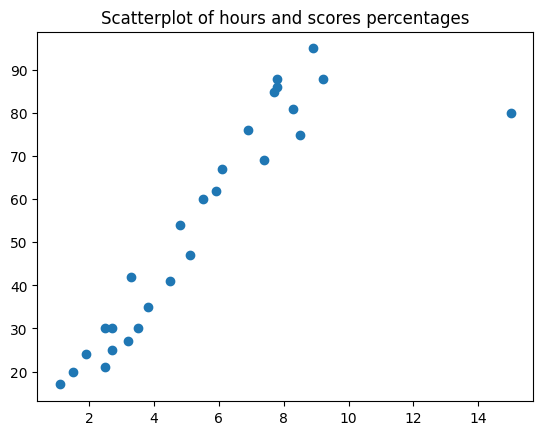

In [107]:
# Univariate analysis: Lets plot scatter graph between x1 and y variable

plt.scatter(x=df['Hours'], y=df['Scores'])
plt.title('Scatterplot of hours and scores percentages')
plt.show() 

# df.plot.scatter(x='Hours', y='Scores', title='Scatterplot of hours and scores percentages')

# Observ: There is a linear relation between x and y

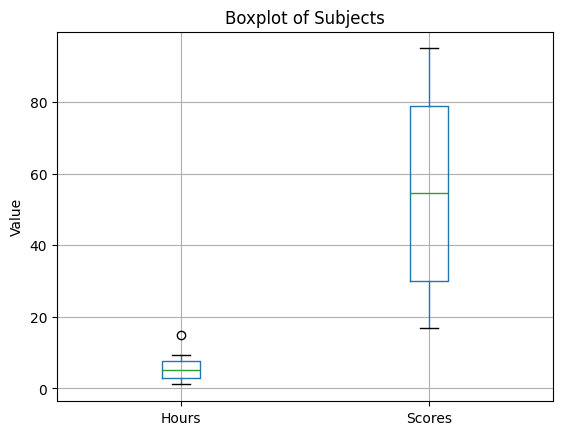

In [108]:
# Univariate analysis: Boxplot for outliers
# (STYLE1: DO NOT USE THIS because the range of values 
# in Hours and Scores differs by wide margin): There are outliers 

df.boxplot()  # or df.plot(kind='box')

plt.title("Boxplot of Subjects")
plt.ylabel("Value")
plt.grid(True)

plt.show()

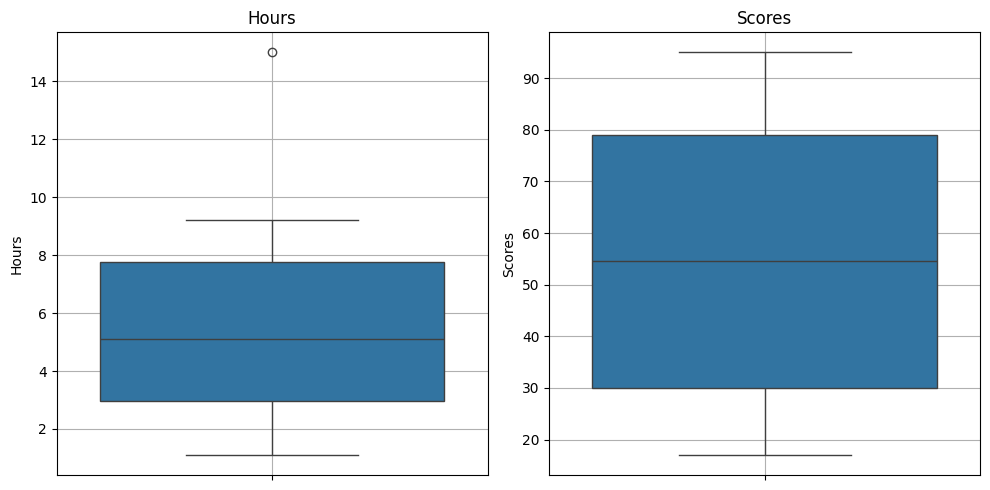

In [109]:
# Boxplot (STYLE2): There are outliers 
import seaborn as sns

# Create a figure with 2 subplots in 1 row
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot for Hours
sns.boxplot(y=df['Hours'], ax=axes[0])
axes[0].set_title('Hours')
axes[0].grid(True)

# Boxplot for Scores
sns.boxplot(y=df['Scores'], ax=axes[1])
axes[1].set_title('Scores')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Boxplot shows:
# Minimum (excluding outliers): The smallest data point still within 1.5 IQR of the lower quartile.
# First Quartile (Q1): 25% of the data fall below this value.
# Median (Q2): The middle value (50% of the data fall below this).
# Third Quartile (Q3): 75% of the data fall below this value.
# Maximum (excluding outliers): The largest data point still within 1.5 IQR of the upper quartile.

# Box Components:
# Box: Spans from Q1 to Q3 (the interquartile range, or IQR). It shows the middle 50% of the data.
# Line inside the box: The median.
# Whiskers: Extend from the box to the minimum and maximum values within 1.5 * IQR from Q1 and Q3.
# Dots (Outliers): Individual points that fall outside the whiskers (i.e., more than 1.5 * IQR from the quartiles).


# What You Can Learn from a Boxplot:
# 1) Central tendency (via the median).
# 2) Spread of the data (via the IQR and whiskers).
# 3) Skewness:
#     If the median is closer to Q1 → right-skewed.
#     If the median is closer to Q3 → left-skewed.

# 4) Presence of outliers.
# 5) Comparison between groups (boxplots are great for side-by-side comparison across categories).

In [110]:
# univariate analysis: Lets find the actual value of this outlier in Hours:
# Step 1: Calculate Q1, Q3 and IQR
Q1 = df['Hours'].quantile(0.25)
Q2 = df['Hours'].quantile(0.5)
Q3 = df['Hours'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1:{Q1}")
print(f"Q2:{Q2}")
print(f"Q3:{Q3}")
print(f"IQR:{IQR}")

# Step 2: Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR 
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter outliers
outliers = df[(df['Hours'] < lower_bound) | (df['Hours'] > upper_bound)]

# Step 4: Print the outliers
print("Outliers in 'Hours' column:")
print(outliers) # print the whole rows
print(outliers['Hours'].values) # print the just the col values

Q1:2.94921875
Q2:5.1015625
Q3:7.75
IQR:4.80078125
Outliers in 'Hours' column:
    Hours  Scores
20   15.0      80
[15.]


In [111]:
# Lets find Q1, Q2 and IQR for Scores
# Step 1: Calculate Q1, Q3 and IQR
Q1 = df['Scores'].quantile(0.25)
Q2 = df['Scores'].quantile(0.5)
Q3 = df['Scores'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1:{Q1}")
print(f"Q2:{Q2}")
print(f"Q3:{Q3}")
print(f"IQR:{IQR}")

# Step 2: Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR #
upper_bound = Q3 + 1.5 * IQR

# Step 3: Filter outliers
outliers = df[(df['Scores'] < lower_bound) | (df['Scores'] > upper_bound)]

# Step 4: Print the outliers
print("Outliers in 'Scores' column:")
print(outliers) # print the whole rows
print(outliers['Scores'].values) # print the just the col values

Q1:30.0
Q2:54.5
Q3:79.0
IQR:49.0
Outliers in 'Scores' column:
Empty DataFrame
Columns: [Hours, Scores]
Index: []
[]


### Alternative: Z-Score Method to Find Outliers

You can also use the z-score method to find outliers (values more than 3 standard deviations from the mean):

In [112]:
from scipy import stats

clean_column = df['Hours'].dropna()
z_scores = np.abs(stats.zscore(clean_column))

# Get the index of non-NaN rows
valid_index = clean_column.index

# Find outliers only in the cleaned rows
outliers_index = valid_index[z_scores > 3]
outliers = df.loc[outliers_index]
print("Outliers:\n", outliers)

Outliers:
     Hours  Scores
20   15.0      80


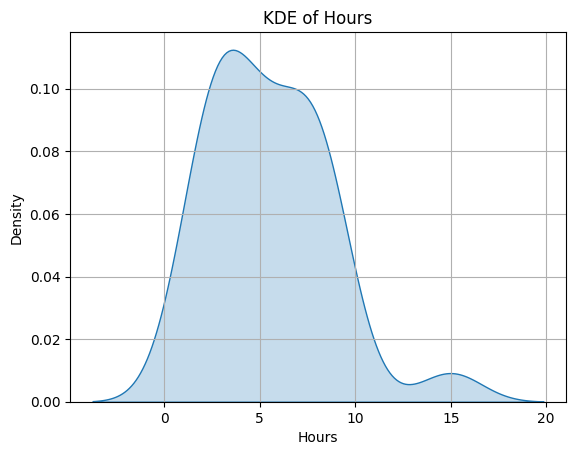

In [113]:
# KDE Plot: A KDE plot is a smooth curve that estimates the probability density function (PDF)
# of a continuous variable.

sns.kdeplot(df['Hours'], fill=True)  # fill=True: Fills the area under the KDE curve with color.'shade=True' in older seaborn versions
plt.title('KDE of Hours')
plt.xlabel('Hours')
plt.ylabel('Density')
plt.grid(True)
plt.show()

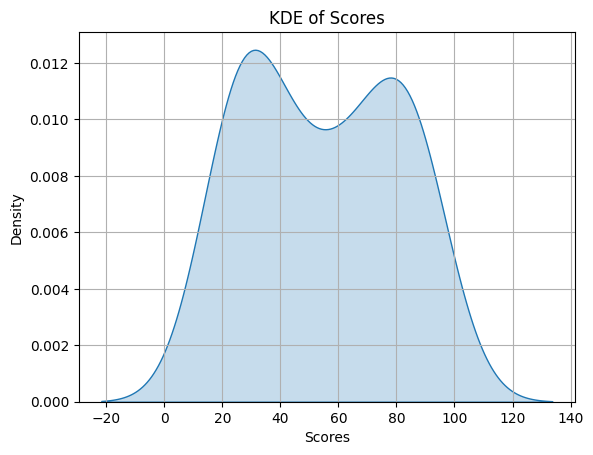

In [114]:

sns.kdeplot(df['Scores'], fill=True)  # fill=True: Fills the area under the KDE curve with color.'shade=True' in older seaborn versions
plt.title('KDE of Scores')
plt.xlabel('Scores')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# 4. Label encoding + Data split: train + test
- **Label encoding is needed in classification task**. Label Score does not need encoding because this is regression problem(predict numerical value of score) 

- Split dataset into train and test set. We would use training data to train the model. The test data is used to evaluate the model.

In [115]:
# Data split:
# step1: Before splitting, seperate your data into feature X and response y

X = df[['Hours']] # This is the feature that would predict the y
y = df['Scores']

In [116]:
# step2: Now we split the dataset into training / testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42 # random state for reproducibility
) 

In [117]:
# step3: Lets see how many records are in training and testing dataset

print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")

X_train shape:(24, 1)
X_test shape:(6, 1)


In [118]:
print(X_train['Hours'])

28          NaN
24     6.898438
12     4.500000
0      2.500000
4      3.500000
16     2.500000
5      1.500000
13     3.300781
11     5.898438
22     4.800781
1      5.101562
2      3.199219
25     7.800781
3      8.500000
21     2.699219
26     7.800781
18     6.101562
29          NaN
20    15.000000
7      5.500000
10     7.699219
14     1.099609
19     7.398438
6      9.203125
Name: Hours, dtype: float16


# 6. Data Preprocessing and Feature Engineering

## Lets check and deal with missing values
- In order to avoid data leakage, **we handle missing values AFTER data split**

In [119]:
# step1) Now lets get the count of missing values for each column/feature

print(X_train.isnull().sum())

Hours    2
dtype: int64


In [121]:
# step2) I want to see the missing values as percentage

# Count missing values per column
missing_values = X_train.isnull().sum()
missing_percentage = (missing_values / len(X_train)) * 100  # Percentage of missing values

# Filter only columns with missing values
missing = pd.DataFrame({'Missing Values': missing_values,
                        'Percentage (%)': missing_percentage
})
missing = missing[missing['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

# Display missing value counts
print("Missing Values Summary:")
print(missing)

Missing Values Summary:
       Missing Values  Percentage (%)
Hours               2        8.333333


In [122]:
# step3) There are lot of options for dealing with missing values. 
# Here I am filling with mean value
# Note: If you drop missing values from X_train, then drop corresponding values from y_train too. 

train_mean = X_train['Hours'].mean()

X_train['Hours'] = X_train['Hours'].fillna(train_mean)

# fill missing values in test data with mean of training data
X_test['Hours']  = X_test['Hours'].fillna(train_mean) 

In [82]:
# step4) Check again for missing values. Now should be 0

print(X_train.isnull().sum())

Hours    0
dtype: int64


### Lets handle outliers

In [124]:
# Step 1: idetify outliers
col = "Hours"

Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1:{Q1}")
print(f"Q3:{Q3}")

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR #
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]

print("Outliers column:\n", outliers)

Q1:3.275390625
Q3:7.4736328125
Outliers column:
     Hours
20   15.0


In [126]:
# step2: Handle them. Here I am capping them(Winsorization)
col = "Hours"
Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

X_train[col] = X_train[col].clip(lower_bound, upper_bound)

In [129]:
print(lower_bound, upper_bound)

-3.02197265625 13.77099609375


In [130]:
# Step 3: Verify outliers are gone
col = "Hours"

Q1 = X_train[col].quantile(0.25)
Q3 = X_train[col].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR #
upper_bound = Q3 + 1.5 * IQR

# Filter outliers
outliers = X_train[(X_train[col] < lower_bound) | (X_train[col] > upper_bound)]

print("Outliers column:\n", outliers)

Outliers column:
 Empty DataFrame
Columns: [Hours]
Index: []


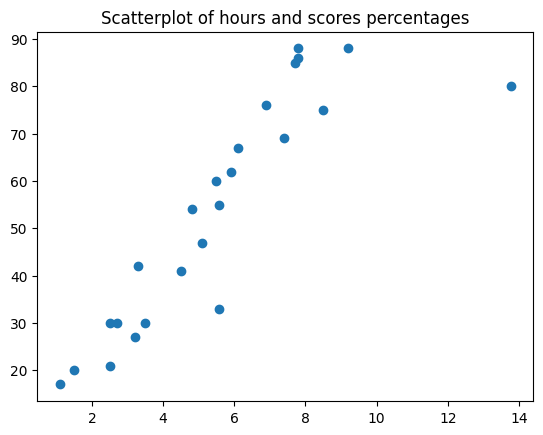

In [86]:
# Univariate analysis: Lets plot scatter graph between x1 and y variable

plt.scatter( x=X_train['Hours'], y=y_train)
plt.title('Scatterplot of hours and scores percentages')
plt.show() 

# df.plot.scatter(x='Hours', y='Scores', title='Scatterplot of hours and scores percentages')

# Observ: There is a linear relation between x and y
# The outlier point is now clipped to 13.77  

# 7. Modelling and Training
Modelling means picking the right model. Here since I am trying to predict a numeric value, so I use regression model. Here I am picking a simple linear regression model

In [122]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Now we train the model. This can take long time
model.fit(X_train, y_train) 

LinearRegression()

In [123]:
# After the model is trined, lets make a prediction on score of a 
# student who studies for hours=9.5, and check against the above plot

sample = pd.DataFrame([9.5,], columns=X_train.columns)

score = model.predict(sample)

print(f"The score is {score}")

The score is [82.48925052]


# (OPTIONAL) Analyze:
## The y intercept
To find the equation of line, 
$$
y = a_0 + a_1 x_1 
$$
we need to find  $a_0$ and $a_1$. We can get that from the above model.

In [124]:
# calculate
a0 = model.intercept_ # intercept
a1 = model.coef_[0] # # x-coefficient or slope

print(f"The intercept a0: {a0}")
print(f"The x-coeff a1: {a1}")

The intercept a0: 13.244103549356709
The x-coeff a1: 7.288962838841845


In [125]:
# Lets round them up
a0 = round(a0,4) # intercept
a1 = round(a1,4) # # x-coefficient or slope

print(f"The intercept: {a0}")
print(f"The x-coeff: {a1}")

The intercept: 13.2441
The x-coeff: 7.289


This can quite literally be plugged in into our formula from before:
$$
y = a0 + a1 ∗ x_1
$$

**score = a0 + a1 ∗ hours**

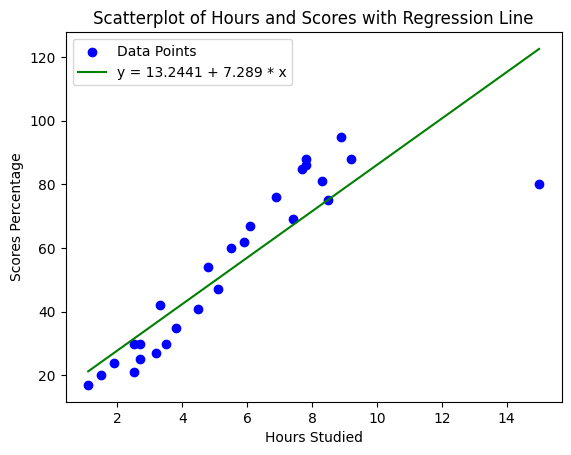

In [126]:
x = df['Hours']
y = df['Scores']

# Create the scatter plot
plt.scatter(x, y, label="Data Points", color="blue")

# Generate x values for the line
x_line = np.linspace(x.min(), x.max(), 100)  # Create a range of x values
y_line = a0 + a1 * x_line   # Compute corresponding y values using the equation

# Plot the regression line
plt.plot(x_line, y_line, color="green", label=f"y = {a0} + {a1} * x")

# Add labels and title
plt.xlabel("Hours Studied")
plt.ylabel("Scores Percentage")
plt.title("Scatterplot of Hours and Scores with Regression Line")

plt.legend() # Show legend

plt.show() # Display the plot

## Lets calculate score manually and also using the predict method

In [127]:
# Lets write a simple code to calculate score based on eqn: 
# score = a0 + a1 * hours
a0 = model.intercept_ # intercept
a1 = model.coef_[0] # # x-coefficient or slope

hours = 9.5
score = a0 + a1 * hours

print(score)

82.48925051835423


In [128]:
new_data = pd.DataFrame([9.5,], columns=X_train.columns)

score = model.predict(new_data)
print(score)

[82.48925052]


### Both are same
So I wanted to show that this predicted value can also be obtained via the line intercept and slope value

In [129]:
# Lets say someone gives you a large dataset to make predictions;
new_data = pd.DataFrame([8.3, 2.5, 5.9], columns=X_train.columns) # hours

# Lets make prediction on test data set
y_pred = model.predict(new_data)
print(y_pred)

[73.74249511 31.46651065 56.2489843 ]


# 8. Model Performance Evaluation


In [130]:
# step1: Lets make prediction on test data set
y_pred = model.predict(X_test)
print(y_pred)

[53.83037517 78.11587003 40.94216199 27.09313277 73.7424965  32.92430356]


In [131]:
# (OPTIONAL) Now lets the see absolute difference between the actual and prediction and also the percentage difference.

df_preds = pd.DataFrame({
    'hours': X_test.squeeze(),
    'actual_score': y_test.squeeze(),
    'predicted_score': y_pred.squeeze()})

df_preds['difference'] = (df_preds['actual_score'] - df_preds['predicted_score']).abs()

# Add the percentage difference column
df_preds['percentage_difference'] = (
    df_preds['difference'] / df_preds['actual_score']
) * 100

print(df_preds)

       hours  actual_score  predicted_score  difference  percentage_difference
27  5.568182            86        53.830375   32.169625              37.406541
15  8.900000            95        78.115870   16.884130              17.772768
23  3.800000            35        40.942162    5.942162              16.977606
17  1.900000            24        27.093133    3.093133              12.888053
8   8.300000            81        73.742497    7.257503               8.959881
9   2.700000            25        32.924304    7.924304              31.697214


##### Observation: Not much difference between actual and predicted score

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute errors
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Compute R-squared (R²) value
r2 = r2_score(y_test, y_pred)

# Compute percentage-based errors
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # Mean Absolute Percentage Error
relative_mae = (mae / np.mean(y_test)) * 100  # Relative MAE
relative_rmse = (rmse / np.mean(y_test)) * 100  # Relative RMSE
nrmse = (rmse / (y_test.max() - y_test.min())) * 100  # Normalized RMSE

# Print all results
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.4f}')  # closer to 1 is good
print("########################")

print(f'Mean Absolute Percentage Error (MAPE): {mape:.2f}%')
print(f'Relative MAE: {relative_mae:.2f}%')
print(f'Relative RMSE: {relative_rmse:.2f}%')
print(f'Normalized RMSE (NRMSE): {nrmse:.2f}%')

Mean Absolute Error (MAE): 12.21
Mean Squared Error (MSE): 246.72
Root Mean Squared Error (RMSE): 15.71
R-squared (R²): 0.7287
########################
Mean Absolute Percentage Error (MAPE): 20.95%
Relative MAE: 21.18%
Relative RMSE: 27.24%
Normalized RMSE (NRMSE): 22.12%


### R-square value looking good

# 9. Hyperparameter tuning


# 10. Final Evaluation

# 11. Model Deloyment: 
### Save the model and then send it to the server and users can  access your model.

In [133]:
# now lets save the model
import joblib

joblib.dump(model, 'linear_regression_model.pkl')

['linear_regression_model.pkl']

# Load the model later

In [134]:
# lets load the model
import joblib

loaded_model = joblib.load('linear_regression_model.pkl')

In [135]:
# make prediction
new_data = pd.DataFrame([9.5,], columns=X_train.columns)

score = loaded_model.predict(new_data)
print(score)


[82.48925052]
